In [76]:
!pip install qiskit qiskit-aer qiskit-nature qiskit-algorithms pyscf matplotlib pandas --quiet

In [77]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.linalg import eigh

from qiskit import transpile
from qiskit.primitives import StatevectorEstimator
from qiskit.circuit.library import efficient_su2
from qiskit.circuit.library import real_amplitudes

from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.second_q.transformers import ActiveSpaceTransformer
from qiskit_nature.second_q.mappers import JordanWignerMapper, ParityMapper
from qiskit_nature.second_q.circuit.library import UCCSD, HartreeFock
from qiskit_nature.second_q.algorithms import GroundStateEigensolver, QEOM
from qiskit_nature.second_q.operators import FermionicOp

from qiskit_algorithms import VQE, NumPyMinimumEigensolver
from qiskit_algorithms.optimizers import SLSQP, COBYLA

from qiskit_aer.noise import NoiseModel, depolarizing_error, ReadoutError
from qiskit_aer.primitives import EstimatorV2 as AerEstimatorV2, SamplerV2 as AerSamplerV2

from qiskit.quantum_info import Statevector

HARTREE_TO_EV = 27.211386245988
EXPERIMENTAL_PI_PISTAR_EV = 7.6
np.random.seed(1)

## Part 1:  **Molecular setup**

In [78]:
def rotate_z(xyz, angle_deg):
    a = np.radians(angle_deg)
    R = np.array([[np.cos(a), -np.sin(a), 0],
                  [np.sin(a),  np.cos(a), 0],
                  [0, 0, 1]])
    return R @ np.array(xyz)

def build_geometry(twist_deg: float = 0.0) -> str:
    atoms = {k: v.copy() for k, v in equilibrium_atoms.items()}
    if twist_deg != 0.0:
        atoms["H3"] = rotate_z(atoms["H3"], twist_deg)
        atoms["H4"] = rotate_z(atoms["H4"], twist_deg)
    order = ["C1", "C2", "H1", "H2", "H3", "H4"]
    return "; ".join(f"{name[0]} {x:.6f} {y:.6f} {z:.6f}" for name in order
                      for x, y, z in [atoms[name]])

def print_geometry(label, geometry):
    print(f"{label}:")
    atoms = geometry.split("; ")
    for i, atom in enumerate(atoms):
        suffix = ";" if i < len(atoms) - 1 else ""
        print(f"  {atom}{suffix}")

# Standard planar equilibrium ethylene geometry (Angstrom)
equilibrium_atoms = {
    "C1": np.array([0.0000,  0.0000,  0.6695]),
    "C2": np.array([0.0000,  0.0000, -0.6695]),
    "H1": np.array([0.0000,  0.9289,  1.2321]),
    "H2": np.array([0.0000, -0.9289,  1.2321]),
    "H3": np.array([0.0000,  0.9289, -1.2321]),
    "H4": np.array([0.0000, -0.9289, -1.2321]),
}


geometry_equilibrium = build_geometry(0.0)
geometry_twisted = build_geometry(90.0)

# print(geometry_equilibrium)
print_geometry("Equilibrium", geometry_equilibrium)
print_geometry("\nTwisted 90", geometry_twisted)

Equilibrium:
  C 0.000000 0.000000 0.669500;
  C 0.000000 0.000000 -0.669500;
  H 0.000000 0.928900 1.232100;
  H 0.000000 -0.928900 1.232100;
  H 0.000000 0.928900 -1.232100;
  H 0.000000 -0.928900 -1.232100

Twisted 90:
  C 0.000000 0.000000 0.669500;
  C 0.000000 0.000000 -0.669500;
  H 0.000000 0.928900 1.232100;
  H 0.000000 -0.928900 1.232100;
  H -0.928900 0.000000 -1.232100;
  H 0.928900 -0.000000 -1.232100


In [79]:
def run_driver(geometry: str, basis: str = "sto3g"):
    driver = PySCFDriver(atom=geometry, basis=basis, charge=0, spin=0)
    return driver.run()

# driver = PySCFDriver(atom=geometry_equilibrium, basis="sto3g", charge=0, spin=0)
full_eq = run_driver(geometry_equilibrium)
print(f"Full STO-3G problem: {full_eq.num_spatial_orbitals} spatial orbitals, {full_eq.num_particles} particles")
print(f"Restricted Hartree-Fock (RHF) reference energy: {full_eq.reference_energy:.6f} Ha")
print(f"Nuclear repulsion energy: {full_eq.hamiltonian.nuclear_repulsion_energy:.6f} Ha")

Full STO-3G problem: 14 spatial orbitals, (8, 8) particles
Restricted Hartree-Fock (RHF) reference energy: -77.072088 Ha
Nuclear repulsion energy: 33.265090 Ha


In [80]:
# Active space: 2 electrons in 2 spatial orbitals (the pi / pi* frontier orbitals).

def ActiveSpaceTransformation(full_problem, num_active_electrons, num_spatial_orbitals):
  as_transformer = ActiveSpaceTransformer(num_electrons=num_active_electrons, num_spatial_orbitals=num_spatial_orbitals)
  as_eq = as_transformer.transform(full_problem)
  print(f"Active-space problem: {as_eq.num_spatial_orbitals} spatial orbitals, "
        f"{as_eq.num_particles} particles")
  print(f"Energy offset absorbed into the classical core (frozen-core + nuclear repulsion): {sum(as_eq.hamiltonian.constants.values()):.6f} Ha")
  return as_eq

# 2 electrons/2 orbitals
active_space_eq = ActiveSpaceTransformation(full_eq, 2, 2)


Active-space problem: 2 spatial orbitals, (1, 1) particles
Energy offset absorbed into the classical core (frozen-core + nuclear repulsion): -75.918420 Ha


In [81]:
# Qubit mapping: Jordan-Wigner vs. Parity mapping + two-qubit tapering
hamiltonian_op = active_space_eq.hamiltonian.second_q_op()

jw_mapper = JordanWignerMapper()
qubit_op_jw = jw_mapper.map(hamiltonian_op)

parity_mapper = ParityMapper(num_particles=active_space_eq.num_particles)
qubit_op_parity = parity_mapper.map(hamiltonian_op)

print(f"Jordan-Wigner mapping : {qubit_op_jw.num_qubits} qubits")
print(f"Parity mapping with tapering (2-qubit reduction) : {qubit_op_parity.num_qubits} qubits")

mapper = jw_mapper

Jordan-Wigner mapping : 4 qubits
Parity mapping with tapering (2-qubit reduction) : 2 qubits


## Part 2:  **Ground-state VQE**
We implement two ansätze on top of the Hartree-Fock reference state:

- UCCSD
- Hardware-efficient ansatz (HEA): we will try EfficientSU2 and RealAmplitudes


In [82]:
hf_state = HartreeFock(active_space_eq.num_spatial_orbitals, active_space_eq.num_particles, mapper)

uccsd_ansatz = UCCSD(active_space_eq.num_spatial_orbitals, active_space_eq.num_particles, mapper, initial_state=hf_state)

hea_core = efficient_su2(qubit_op_jw.num_qubits, reps=2, entanglement="linear")
hea_ansatz = hf_state.compose(hea_core)

rea_core = real_amplitudes(qubit_op_jw.num_qubits, reps=2, entanglement="linear")
rea_ansatz = hf_state.compose(rea_core)

ansatz_stats = pd.DataFrame([
    {"Ansatz": "UCCSD", "Qubits": uccsd_ansatz.num_qubits,
     "Parameters": uccsd_ansatz.num_parameters,
     "Depth (decomposed)": uccsd_ansatz.decompose(reps=3).depth()},
    {"Ansatz": "Hardware-efficient (EfficientSU2, reps=2)", "Qubits": hea_ansatz.num_qubits,
     "Parameters": hea_ansatz.num_parameters,
     "Depth (decomposed)": hea_ansatz.decompose(reps=2).depth()},
    {"Ansatz": "Hardware-efficient (RealAmplitudes, reps=2)", "Qubits": rea_ansatz.num_qubits,
     "Parameters": rea_ansatz.num_parameters,
     "Depth (decomposed)": rea_ansatz.decompose(reps=2).depth()},
])
ansatz_stats

,Ansatz,Qubits,Parameters,Depth (decomposed)
0,UCCSD,4,3,112
1,"Hardware-efficient (EfficientSU2, reps=2)",4,24,12
2,"Hardware-efficient (RealAmplitudes, reps=2)",4,12,9


In [83]:
def run_vqe(ansatz, problem, mapper, optimizer, initial_point=None, estimator=None):
    '''Run VQE (statevector, noise-free by default) and return (result, history).'''
    estimator = estimator or StatevectorEstimator()
    history = []
    def callback(eval_count, params, value, meta):
        history.append(value)
    vqe = VQE(estimator, ansatz, optimizer, callback=callback)
    vqe.initial_point = (initial_point if initial_point is not None
                          else np.zeros(ansatz.num_parameters))
    solver = GroundStateEigensolver(mapper, vqe)
    result = solver.solve(problem)
    return result, history, vqe

result_uccsd, history_uccsd, vqe_uccsd = run_vqe(
    uccsd_ansatz, active_space_eq, mapper, SLSQP(maxiter=200))

rng = np.random.default_rng(1)
result_hea, history_hea, vqe_hea = run_vqe(
    hea_ansatz, active_space_eq, mapper, COBYLA(maxiter=300),
    initial_point=rng.uniform(-0.1, 0.1, hea_ansatz.num_parameters))

rng2 = np.random.default_rng(1)
result_rea, history_rea, vqe_rea = run_vqe(
    rea_ansatz, active_space_eq, mapper, COBYLA(maxiter=300),
    initial_point=rng2.uniform(-0.1, 0.1, rea_ansatz.num_parameters))

exact_result = GroundStateEigensolver(mapper, NumPyMinimumEigensolver()).solve(active_space_eq)
exact_energy_eq = exact_result.total_energies[0]

print(f"Exact ground energy : {exact_energy_eq:.8f} Ha")
print(f"VQE UCCSD ground energy : {result_uccsd.total_energies[0]:.8f} Ha "
      f"(Δ = {(result_uccsd.total_energies[0]-exact_energy_eq)*1000:.4f} mHa)")
print(f"VQE hardware-efficient ansatz ground energy : {result_hea.total_energies[0]:.8f} Ha "
      f"(Δ = {(result_hea.total_energies[0]-exact_energy_eq)*1000:.4f} mHa)")
print(f"VQE RealAmplitudes ground energy : {result_rea.total_energies[0]:.8f} Ha "
      f"(Δ = {(result_rea.total_energies[0]-exact_energy_eq)*1000:.4f} mHa)")

Exact ground energy : -77.11659291 Ha
VQE UCCSD ground energy : -77.11659291 Ha (Δ = 0.0000 mHa)
VQE hardware-efficient ansatz ground energy : -77.11640764 Ha (Δ = 0.1853 mHa)
VQE RealAmplitudes ground energy : -77.11648733 Ha (Δ = 0.1056 mHa)


In [84]:
# Ground state at the twisted (90 deg) geometry
full_eq_tw = run_driver(geometry_twisted)
print("For twisted (90 deg) geometry:")
as_problem_tw = ActiveSpaceTransformation(full_eq_tw, 2, 2)
result_uccsd_tw, history_uccsd_tw, vqe_uccsd_tw = run_vqe(
    UCCSD(as_problem_tw.num_spatial_orbitals, as_problem_tw.num_particles, mapper,
          initial_state=HartreeFock(as_problem_tw.num_spatial_orbitals, as_problem_tw.num_particles, mapper)),
    as_problem_tw, mapper, SLSQP(maxiter=200))

gse_uccsd = GroundStateEigensolver(mapper, vqe_uccsd)

print(f"\nVQE UCCSD ground energy (equilibrium): {result_uccsd.total_energies[0]:.6f} Ha")
print(f"VQE UCCSD ground energy (twisted 90°) : {result_uccsd_tw.total_energies[0]:.6f} Ha")
print(f"Torsional barrier estimate : "
      f"{(result_uccsd_tw.total_energies[0]-result_uccsd.total_energies[0])*HARTREE_TO_EV:.3f} eV")

For twisted (90 deg) geometry:
Active-space problem: 2 spatial orbitals, (1, 1) particles
Energy offset absorbed into the classical core (frozen-core + nuclear repulsion): -76.032051 Ha

VQE UCCSD ground energy (equilibrium): -77.116593 Ha
VQE UCCSD ground energy (twisted 90°) : -76.976930 Ha
Torsional barrier estimate : 3.800 eV


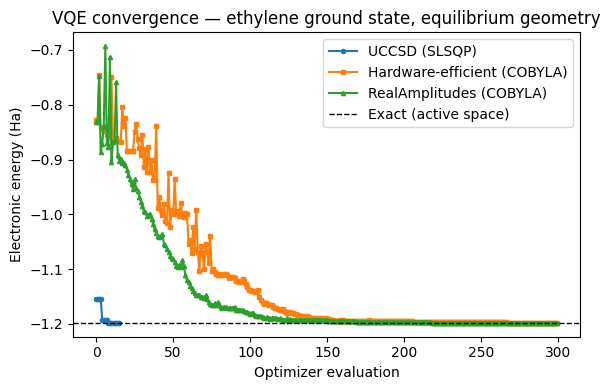

In [85]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(history_uccsd, label="UCCSD (SLSQP)", marker="o", ms=3)
ax.plot(history_hea, label="Hardware-efficient (COBYLA)", marker="s", ms=3)
ax.plot(history_rea, label="RealAmplitudes (COBYLA)", marker="^", ms=3)
ax.axhline(exact_result.eigenvalues[0], color="k", ls="--", lw=1, label="Exact (active space)")
ax.set_xlabel("Optimizer evaluation")
ax.set_ylabel("Electronic energy (Ha)")
ax.set_title("VQE convergence — ethylene ground state, equilibrium geometry")
ax.legend()
plt.tight_layout()
plt.show()

## Part 3:  **Excited states via QSE**

In [86]:
def build_excitation_ops(num_spatial_orbitals, num_particles):
    """Single + double excitation operators (alpha/beta) for the active space."""
    n_so = 2 * num_spatial_orbitals
    n_occ_a, n_occ_b = num_particles
    occ_a = list(range(n_occ_a))
    occ_b = list(range(num_spatial_orbitals, num_spatial_orbitals + n_occ_b))
    vir_a = list(range(n_occ_a, num_spatial_orbitals))
    vir_b = list(range(num_spatial_orbitals + n_occ_b, n_so))

    ops = []
    for i in occ_a:                       # alpha singles
        for a in vir_a:
            ops.append(FermionicOp({f"+_{a} -_{i}": 1.0}, num_spin_orbitals=n_so))
    for i in occ_b:                       # beta singles
        for a in vir_b:
            ops.append(FermionicOp({f"+_{a} -_{i}": 1.0}, num_spin_orbitals=n_so))
    for i in occ_a:                       # alpha-beta doubles
        for j in occ_b:
            for a in vir_a:
                for b in vir_b:
                    ops.append(FermionicOp({f"+_{a} +_{b} -_{j} -_{i}": 1.0}, num_spin_orbitals=n_so))
    return ops

def run_qse(ground_state_solver, problem, mapper):
    # 1. Solve VQE, get the ground-state statevector
    gs_result = ground_state_solver.solve(problem)
    optimal_circuit = gs_result.raw_result.optimal_circuit.assign_parameters(
        gs_result.raw_result.optimal_point
    )
    psi0 = Statevector(optimal_circuit).data

    # 2. Hamiltonian as a dense matrix
    H = mapper.map(problem.hamiltonian.second_q_op()).to_matrix()

    # 3. Build the subspace {|psi0>, E_i|psi0>} for each excitation operator
    fermionic_ops = build_excitation_ops(problem.num_spatial_orbitals, problem.num_particles)
    op_matrices = [np.eye(H.shape[0])] + [mapper.map(op).to_matrix() for op in fermionic_ops]
    subspace_states = [op @ psi0 for op in op_matrices]

    # 4. Solve the generalized eigenvalue problem  H C = E S C
    n = len(subspace_states)
    H_sub = np.zeros((n, n), dtype=complex)
    S_sub = np.zeros((n, n), dtype=complex)
    for i in range(n):
        for j in range(n):
            H_sub[i, j] = np.vdot(subspace_states[i], H @ subspace_states[j])
            S_sub[i, j] = np.vdot(subspace_states[i], subspace_states[j])

    return eigh(H_sub, S_sub, eigvals_only=True)

qse_energies_eq = run_qse(gse_uccsd, active_space_eq, mapper)
excitation_eq_eV_qse = (qse_energies_eq - qse_energies_eq[0]) * HARTREE_TO_EV

print("QSE ground and excited electronic energies (Ha):", np.round(qse_energies_eq, 6))
print("QSE excitation energies relative to the ground state (eV):", np.round(excitation_eq_eV_qse, 4))
print(f"\nQSE computed vertical pi -> pi* excitation energy : {excitation_eq_eV_qse[2]:.3f} eV")
print(f"Experimental reference : {EXPERIMENTAL_PI_PISTAR_EV} eV")
print(f"Difference : {excitation_eq_eV_qse[2]-EXPERIMENTAL_PI_PISTAR_EV:+.3f} eV")

QSE ground and excited electronic energies (Ha): [-1.198173 -1.022076 -0.678003 -0.488654]
QSE excitation energies relative to the ground state (eV): [ 0.      4.7918 14.1545 19.307 ]

QSE computed vertical pi -> pi* excitation energy : 14.155 eV
Experimental reference : 7.6 eV
Difference : +6.555 eV


In [87]:
# Same analysis at the twisted (90 deg) geometry: the pi bond is broken, so the
# pi/pi* levels should become close to degenerate (diradical character).
gse_uccsd_tw = GroundStateEigensolver(mapper, vqe_uccsd_tw)
qse_energies_tw = run_qse(gse_uccsd_tw, as_problem_tw, mapper)
excitation_tw_eV = (qse_energies_tw - qse_energies_tw[0]) * HARTREE_TO_EV
print("Twisted-geometry excitation energies (eV):", np.round(excitation_tw_eV, 4))

Twisted-geometry excitation energies (eV): [0.     0.0696 6.6498 6.7195]


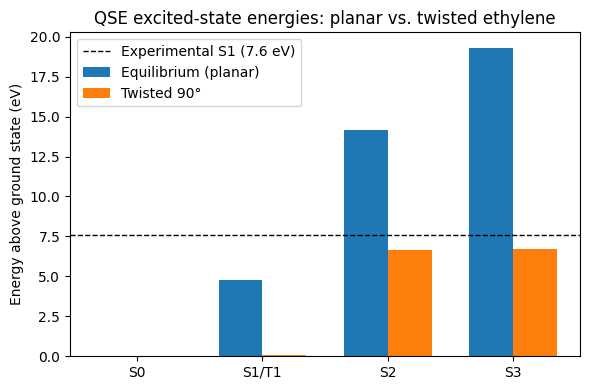

Note the S1 gap collapses at 90° twist — the signature of the conical-intersection region that mediates cis/trans photoisomerization.


In [88]:
fig, ax = plt.subplots(figsize=(6, 4))
labels = ["S0", "S1/T1", "S2", "S3"]
x = np.arange(len(labels))
width = 0.35
ax.bar(x - width/2, excitation_eq_eV_qse, width, label="Equilibrium (planar)")
ax.bar(x + width/2, excitation_tw_eV, width, label="Twisted 90°")
ax.axhline(EXPERIMENTAL_PI_PISTAR_EV, color="k", ls="--", lw=1,
           label=f"Experimental S1 ({EXPERIMENTAL_PI_PISTAR_EV} eV)")
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel("Energy above ground state (eV)")
ax.set_title("QSE excited-state energies: planar vs. twisted ethylene")
ax.legend()
plt.tight_layout()
plt.show()
print("Note the S1 gap collapses at 90° twist — the signature of the conical-"
      "intersection region that mediates cis/trans photoisomerization.")

we can try aug-cc-pvdz active space to improve the accuracy of the excitation energy, because sto3g is a minimal basis and the absence of dynamic correlation and diffuse functions.

In [89]:
def run_full_pipeline(basis):
    full = run_driver(geometry_equilibrium, basis=basis)
    as_problem = ActiveSpaceTransformation(full, 2, 2)
    hf = HartreeFock(as_problem.num_spatial_orbitals, as_problem.num_particles, mapper)
    ansatz = UCCSD(as_problem.num_spatial_orbitals, as_problem.num_particles, mapper, initial_state=hf)
    result, history, vqe = run_vqe(ansatz, as_problem, mapper, SLSQP(maxiter=200))
    gse = GroundStateEigensolver(mapper, vqe)
    energies = run_qse(gse, as_problem, mapper)
    return (energies - energies[0]) * HARTREE_TO_EV, full.num_spatial_orbitals

basis_results = {}
for basis in ["sto3g", "aug-cc-pvdz"]:
    exc_eV, nbasis = run_full_pipeline(basis)
    basis_results[basis] = exc_eV
    print(f"{basis:12s} ({nbasis:3d} basis fns): pi -> pi* excitation = {exc_eV[2]:.3f} eV "
          f"(Δ vs experiment = {exc_eV[2]-EXPERIMENTAL_PI_PISTAR_EV:+.3f} eV)")

Active-space problem: 2 spatial orbitals, (1, 1) particles
Energy offset absorbed into the classical core (frozen-core + nuclear repulsion): -75.918420 Ha
sto3g        ( 14 basis fns): pi -> pi* excitation = 14.155 eV (Δ vs experiment = +6.555 eV)
Active-space problem: 2 spatial orbitals, (1, 1) particles
Energy offset absorbed into the classical core (frozen-core + nuclear repulsion): -76.854329 Ha
aug-cc-pvdz  ( 82 basis fns): pi -> pi* excitation = 7.565 eV (Δ vs experiment = -0.035 eV)


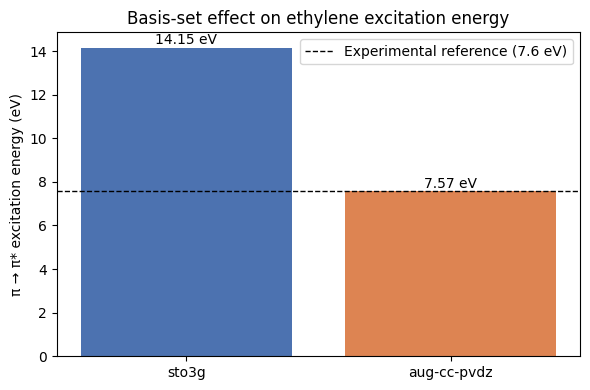

In [90]:
fig, ax = plt.subplots(figsize=(6, 4))
bases = list(basis_results.keys())
############
values = [basis_results[b][2] for b in bases]

bars = ax.bar(bases, values, color=["#4C72B0", "#DD8452"])
ax.axhline(EXPERIMENTAL_PI_PISTAR_EV, color="k", ls="--", lw=1,
           label=f"Experimental reference ({EXPERIMENTAL_PI_PISTAR_EV} eV)")
for bar, v in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.15, f"{v:.2f} eV", ha="center")

ax.set_ylabel("π → π* excitation energy (eV)")
ax.set_title("Basis-set effect on ethylene excitation energy")
ax.legend()
plt.tight_layout()
plt.show()

In [91]:
# --- aug-cc-pVDZ: equilibrium + twisted geometry, ground state + QSE -------
basis_aug = "aug-cc-pvdz"

full_eq_aug = run_driver(geometry_equilibrium, basis=basis_aug)
as_problem_eq_aug = ActiveSpaceTransformation(full_eq_aug, 2, 2)
hf_eq_aug = HartreeFock(as_problem_eq_aug.num_spatial_orbitals, as_problem_eq_aug.num_particles, mapper)
ansatz_eq_aug = UCCSD(as_problem_eq_aug.num_spatial_orbitals, as_problem_eq_aug.num_particles, mapper, initial_state=hf_eq_aug)
result_eq_aug, history_eq_aug, vqe_uccsd_eq_aug = run_vqe(ansatz_eq_aug, as_problem_eq_aug, mapper, SLSQP(maxiter=200))

gse_uccsd_eq_aug = GroundStateEigensolver(mapper, vqe_uccsd_eq_aug)
qse_energies_eq_aug = run_qse(gse_uccsd_eq_aug, as_problem_eq_aug, mapper)
excitation_eq_eV_aug = (qse_energies_eq_aug - qse_energies_eq_aug[0]) * HARTREE_TO_EV
print("aug-cc-pVDZ equilibrium excitation energies (eV):", np.round(excitation_eq_eV_aug, 4))

full_tw_aug = run_driver(geometry_twisted, basis=basis_aug)
as_problem_tw_aug = ActiveSpaceTransformation(full_tw_aug, 2, 2)
hf_tw_aug = HartreeFock(as_problem_tw_aug.num_spatial_orbitals, as_problem_tw_aug.num_particles, mapper)
ansatz_tw_aug = UCCSD(as_problem_tw_aug.num_spatial_orbitals, as_problem_tw_aug.num_particles, mapper, initial_state=hf_tw_aug)
result_tw_aug, history_tw_aug, vqe_uccsd_tw_aug = run_vqe(ansatz_tw_aug, as_problem_tw_aug, mapper, SLSQP(maxiter=200))

gse_uccsd_tw_aug = GroundStateEigensolver(mapper, vqe_uccsd_tw_aug)
qse_energies_tw_aug = run_qse(gse_uccsd_tw_aug, as_problem_tw_aug, mapper)
excitation_tw_eV_aug = (qse_energies_tw_aug - qse_energies_tw_aug[0]) * HARTREE_TO_EV
print("aug-cc-pVDZ twisted-geometry excitation energies (eV):", np.round(excitation_tw_eV_aug, 4))

Active-space problem: 2 spatial orbitals, (1, 1) particles
Energy offset absorbed into the classical core (frozen-core + nuclear repulsion): -76.854329 Ha
aug-cc-pVDZ equilibrium excitation energies (eV): [ 0.      7.5131  7.5652 22.6309]
Active-space problem: 2 spatial orbitals, (1, 1) particles
Energy offset absorbed into the classical core (frozen-core + nuclear repulsion): -76.975382 Ha
aug-cc-pVDZ twisted-geometry excitation energies (eV): [0.     0.0533 2.8618 3.4241]


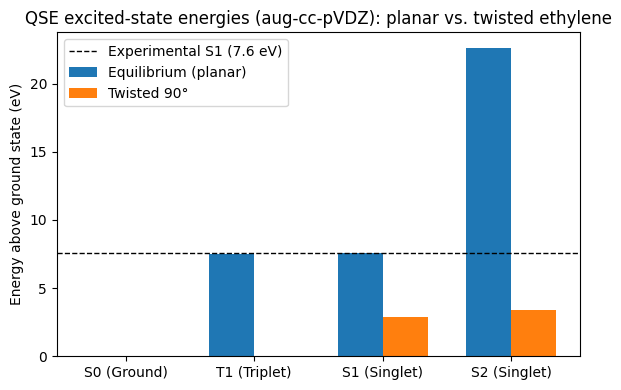

In [94]:
fig, ax = plt.subplots(figsize=(6, 4))
# labels = ["S0", "S1/T1", "S2", "S3"]
labels = ["S0 (Ground)", "T1 (Triplet)", "S1 (Singlet)", "S2 (Singlet)"]
x = np.arange(len(labels))
width = 0.35
ax.bar(x - width/2, excitation_eq_eV_aug, width, label="Equilibrium (planar)")
ax.bar(x + width/2, excitation_tw_eV_aug, width, label="Twisted 90°")
ax.axhline(EXPERIMENTAL_PI_PISTAR_EV, color="k", ls="--", lw=1,
           label=f"Experimental S1 ({EXPERIMENTAL_PI_PISTAR_EV} eV)")
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel("Energy above ground state (eV)")
ax.set_title("QSE excited-state energies (aug-cc-pVDZ): planar vs. twisted ethylene")
ax.legend()
plt.tight_layout()
plt.show()

In [93]:
import pandas as pd

comparison_data = {
    "Root": [0, 1, 2, 3],
    "STO-3G": [f"{val:.3f} eV" for val in excitation_eq_eV_qse[:4]],
    "aug-cc-pVDZ": [f"{val:.3f} eV" for val in excitation_eq_eV_aug[:4]],
    "Spin": ["Singlet (ground)", "Triplet (T1)", "Singlet (S1)", "Singlet (S2)"]
}

df_roots = pd.DataFrame(comparison_data)

# Render the table cleanly without the pandas index column
display(df_roots.style.hide(axis="index").set_properties(**{'text-align': 'left'}))

Root,STO-3G,aug-cc-pVDZ,Spin
0,0.000 eV,0.000 eV,Singlet (ground)
1,4.792 eV,7.513 eV,Triplet (T1)
2,14.155 eV,7.565 eV,Singlet (S1)
3,19.307 eV,22.631 eV,Singlet (S2)


In [96]:
!pip install qiskit-ibm-runtime --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 32.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 412.6/412.6 kB 17.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 120.8/120.8 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.7/95.7 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 234.2/234.2 kB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.6/76.6 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.2/130.2 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 541.5/541.5 kB 22.9 MB/s eta 0:00:00


In [100]:
from qiskit_ibm_runtime import QiskitRuntimeService, EstimatorV2, EstimatorOptions
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

# 1. Authenticate with IBM Quantum
# (Uncomment and insert your token the very first time you run this)
#QiskitRuntimeService.save_account(channel="ibm_quantum_platform", token="1P4_1AXsUIkZXeIFU8KiKc8AdodKKmhK1Neov6uI7sIp", set_as_default=True)

service = QiskitRuntimeService()
backend = service.least_busy(operational=True, simulator=False, min_num_qubits=4)
print(f"Selected Real Backend: {backend.name}")

# 2. Grab your pre-optimized parameters from your local VQE run
optimal_params = result_uccsd.raw_result.optimal_point
core_offset = sum(active_space_eq.hamiltonian.constants.values())

# 3. ISA Transpilation (Mandatory for real hardware)
# This maps your ideal circuit and Hamiltonian to the physical qubits on the chip
pm = generate_preset_pass_manager(target=backend.target, optimization_level=3)
ansatz_isa = pm.run(uccsd_ansatz)
qubit_op_isa = qubit_op_jw.apply_layout(ansatz_isa.layout)

# 4. Enable Hardware Error Mitigation (ZNE & Readout)
options = EstimatorOptions()
options.default_shots = 8000
# resilience_level=2 automatically applies Zero-Noise Extrapolation (ZNE) and Readout Mitigation
options.resilience_level = 2

# 5. Submit the single evaluation job
hw_estimator = EstimatorV2(mode=backend, options=options)
print(f"Submitting job to {backend.name} queue... (This may take hours depending on IBM traffic)")

# This will block your notebook until the IBM queue finishes your job
job = hw_estimator.run([(ansatz_isa, qubit_op_isa, optimal_params)])
hw_electronic_energy = float(job.result()[0].data.evs)
hw_total_energy = hw_electronic_energy + core_offset

print(f"\n--- Real Hardware Results ({backend.name}) ---")
print(f"Exact ground energy      : {exact_energy_eq:.6f} Ha")
print(f"Hardware total energy    : {hw_total_energy:.6f} Ha")
print(f"Hardware Error (mHa)     : {(hw_total_energy - exact_energy_eq) * 1000:.2f} mHa")

qiskit_runtime_service.__init__:WARNING:2026-09-07 14:02:40,905: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService(). Alternatively, pass instance='auto' or save it to your account for auto-selection without warning.
qiskit_runtime_service.backends:WARNING:2026-09-07 14:02:41,356: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-09-07 14:02:44,270: Using instance: open-instance, plan: open


Selected Real Backend: ibm_fez
Submitting job to ibm_fez queue... (This may take hours depending on IBM traffic)
\n--- Real Hardware Results (ibm_fez) ---
Exact ground energy      : -77.116593 Ha
Hardware total energy    : -77.097904 Ha
Hardware Error (mHa)     : 18.69 mHa
